In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, zipfile, json
import pandas as pd
import torch

# Verificar GPU
assert torch.cuda.is_available(), "❌ GPU no activada. Ve a Runtime > Change runtime type"
device = torch.device('cuda')
print(f"✅ GPU: {torch.cuda.get_device_name(0)}")

# Descomprimir si es necesario
zip_path = '/content/drive/MyDrive/plantvillage_proyecto/data/plantvillage-dataset.zip'
local_extract = '/content/dataset'
if not os.path.exists(os.path.join(local_extract, 'plantvillage dataset', 'color')):
    print("⏳ Descomprimiendo dataset (3-5 min)...")
    os.makedirs(local_extract, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(local_extract)
    print("✅ Descomprimido")
else:
    print("✅ Dataset ya descomprimido")

# Cargar config y splits
with open('/content/drive/MyDrive/plantvillage_proyecto/data/config.json') as f:
    config = json.load(f)
with open('/content/drive/MyDrive/plantvillage_proyecto/data/class_mapping.json') as f:
    mapping = json.load(f)

class_to_idx = mapping['class_to_idx']
idx_to_class = {int(k): v for k, v in mapping['idx_to_class'].items()}
NUM_CLASSES = config['NUM_CLASSES']

splits_path = '/content/drive/MyDrive/plantvillage_proyecto/data'
train_df = pd.read_csv(f'{splits_path}/train_split.csv')
val_df   = pd.read_csv(f'{splits_path}/val_split.csv')
test_df  = pd.read_csv(f'{splits_path}/test_split.csv')

# Corregir rutas a local
def fix_path(p):
    return f'/content/dataset/plantvillage dataset/color/{p.split("color/")[1]}'

for df in [train_df, val_df, test_df]:
    df['image_path'] = df['image_path'].apply(fix_path)
    df['label'] = df['class'].map(class_to_idx)

print(f"\n✅ Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}")
print(f"✅ Clases: {NUM_CLASSES}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ GPU: Tesla T4
✅ Dataset ya descomprimido

✅ Train: 38,013  |  Val: 8,146  |  Test: 8,146
✅ Clases: 38


In [2]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

IMG_SIZE = 224
BATCH_SIZE = 64
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.3),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
    transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class PlantVillageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, row['label']

train_dataset = PlantVillageDataset(train_df, train_transforms)
val_dataset   = PlantVillageDataset(val_df,   eval_transforms)
test_dataset  = PlantVillageDataset(test_df,  eval_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

print(f"✅ DataLoaders listos: {len(train_loader)} train batches")

✅ DataLoaders listos: 594 train batches


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [3]:
import torch.nn as nn

class BaselineCNN(nn.Module):
    """CNN sencilla desde cero para servir de línea base."""
    def __init__(self, num_classes=38):
        super().__init__()
        self.features = nn.Sequential(
            # Bloque 1: 224x224 -> 112x112
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Bloque 2: 112x112 -> 56x56
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Bloque 3: 56x56 -> 28x28
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Bloque 4: 28x28 -> 14x14
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),     # 14x14 -> 1x1
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = BaselineCNN(num_classes=NUM_CLASSES).to(device)

# Contar parámetros
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Modelo: BaselineCNN")
print(f"   • Parámetros totales: {total_params:,}")
print(f"   • Parámetros entrenables: {trainable_params:,}")
print(f"\nArquitectura:")
print(model)

✅ Modelo: BaselineCNN
   • Parámetros totales: 427,174
   • Parámetros entrenables: 427,174

Arquitectura:
BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 2

In [4]:
import time
from torch.cuda.amp import autocast, GradScaler

def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        with autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * imgs.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)
    return total_loss/total, correct/total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        with autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)
    return total_loss/total, correct/total

print("✅ Funciones de train/eval definidas")

✅ Funciones de train/eval definidas


In [5]:
EPOCHS = 8
LR = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = GradScaler()

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0
models_path = '/content/drive/MyDrive/plantvillage_proyecto/models'
os.makedirs(models_path, exist_ok=True)

print(f"🚀 Iniciando entrenamiento: {EPOCHS} épocas")
print("=" * 70)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - t0
    print(f"Época {epoch:2d}/{EPOCHS}  |  "
          f"Train loss: {train_loss:.4f} acc: {train_acc:.4f}  |  "
          f"Val loss: {val_loss:.4f} acc: {val_acc:.4f}  |  "
          f"⏱️ {elapsed/60:.1f} min")

    # Guardar el mejor modelo
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f'{models_path}/baseline_cnn_best.pth')
        print(f"   💾 Nuevo mejor modelo guardado (val_acc: {val_acc:.4f})")

print("=" * 70)
print(f"✅ Entrenamiento terminado. Mejor val_acc: {best_val_acc:.4f}")

🚀 Iniciando entrenamiento: 8 épocas


/tmp/ipykernel_1928/3359999654.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_1928/3603262644.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_1928/3603262644.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` i

Época  1/8  |  Train loss: 1.8580 acc: 0.4710  |  Val loss: 1.0635 acc: 0.6715  |  ⏱️ 5.3 min
   💾 Nuevo mejor modelo guardado (val_acc: 0.6715)
Época  2/8  |  Train loss: 1.1437 acc: 0.6487  |  Val loss: 0.6743 acc: 0.7997  |  ⏱️ 5.2 min
   💾 Nuevo mejor modelo guardado (val_acc: 0.7997)
Época  3/8  |  Train loss: 0.8922 acc: 0.7188  |  Val loss: 0.5039 acc: 0.8376  |  ⏱️ 5.3 min
   💾 Nuevo mejor modelo guardado (val_acc: 0.8376)
Época  4/8  |  Train loss: 0.7271 acc: 0.7692  |  Val loss: 0.3964 acc: 0.8779  |  ⏱️ 5.2 min
   💾 Nuevo mejor modelo guardado (val_acc: 0.8779)
Época  5/8  |  Train loss: 0.6093 acc: 0.8039  |  Val loss: 0.2946 acc: 0.9088  |  ⏱️ 5.1 min
   💾 Nuevo mejor modelo guardado (val_acc: 0.9088)
Época  6/8  |  Train loss: 0.5272 acc: 0.8351  |  Val loss: 0.2471 acc: 0.9224  |  ⏱️ 5.1 min
   💾 Nuevo mejor modelo guardado (val_acc: 0.9224)
Época  7/8  |  Train loss: 0.4694 acc: 0.8476  |  Val loss: 0.2159 acc: 0.9332  |  ⏱️ 5.2 min
   💾 Nuevo mejor modelo guardado (va

In [6]:
# Cargar el mejor modelo
model.load_state_dict(torch.load(f'{models_path}/baseline_cnn_best.pth'))
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"📊 Resultados del modelo BaselineCNN en TEST:")
print(f"   • Test Loss:     {test_loss:.4f}")
print(f"   • Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

/tmp/ipykernel_1928/3603262644.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


📊 Resultados del modelo BaselineCNN en TEST:
   • Test Loss:     0.2021
   • Test Accuracy: 0.9391 (93.91%)


✅ History guardado


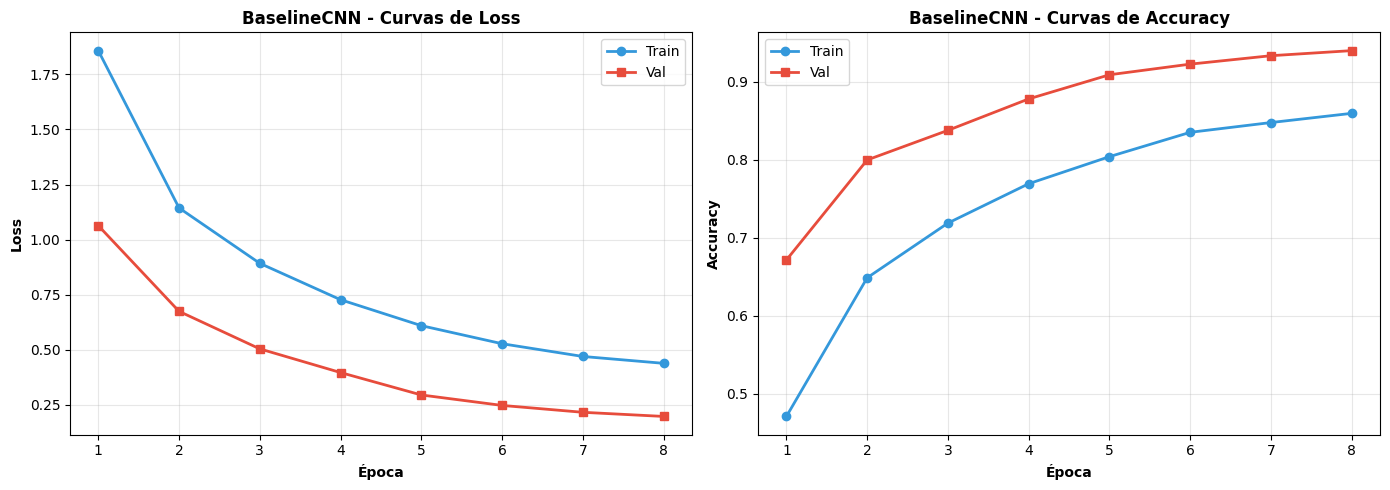

✅ Gráfica guardada


In [7]:
import matplotlib.pyplot as plt

# Guardar history
fig_path = '/content/drive/MyDrive/plantvillage_proyecto/figuras'
os.makedirs(fig_path, exist_ok=True)

with open(f'{models_path}/baseline_cnn_history.json', 'w') as f:
    json.dump({
        'history': history,
        'test_acc': test_acc,
        'test_loss': test_loss,
        'best_val_acc': best_val_acc,
        'epochs': EPOCHS,
        'total_params': total_params,
    }, f, indent=2)
print("✅ History guardado")

# Gráfica curvas de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_x = range(1, EPOCHS + 1)

axes[0].plot(epochs_x, history['train_loss'], 'o-', label='Train', color='#3498db', linewidth=2)
axes[0].plot(epochs_x, history['val_loss'],   's-', label='Val',   color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Época', fontweight='bold')
axes[0].set_ylabel('Loss', fontweight='bold')
axes[0].set_title('BaselineCNN - Curvas de Loss', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, history['train_acc'], 'o-', label='Train', color='#3498db', linewidth=2)
axes[1].plot(epochs_x, history['val_acc'],   's-', label='Val',   color='#e74c3c', linewidth=2)
axes[1].set_xlabel('Época', fontweight='bold')
axes[1].set_ylabel('Accuracy', fontweight='bold')
axes[1].set_title('BaselineCNN - Curvas de Accuracy', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{fig_path}/08_baseline_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Gráfica guardada")